# DWR Outlier Detection Tests + Machine-Learning Ready Dataset

Five groups across multiple state and federal organizations monitor water quality and quantity through a network of instruments located within water bodies across California. [Here](https://cdec.water.ca.gov/webgis/?appid=cdecstation) is a map of all the instruments (select sensor type: other).

Currently, all five organizations implement different pipelines to read, process, store, and serve the data. We propose to create a prototype machine-learning ready dataset that demonstrates a unified pipeline to create a consistent, reproducible, and easily accessible datataset. 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime as dt_obj
from IPython.display import display
from vtools.functions import error_detect
 
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 3000)

## Data processing

To process the data, we will implement standardized outlier detection methods as outlined in the [Outlier Detection Test Best Practices](https://docs.google.com/document/d/1YmXWDMHCKnWniQ4sMkkT5g5j5H5TmT3f/edit?usp=drive_link&ouid=112329730124000397523&rtpof=true&sd=true) guide. Group 3 includes suggested tests, which we can supplement with other ideas (e.g. [Talagala+2019](https://doi.org/10.1029/2019WR024906)). 

First, we will start by implementing some tests on sample data. 

In [8]:
def get_data_from_local_directory(filename, path):
    """
        Get data from a local directory.

        Parameters
        ----------
        filename : str
            Name of file to get from local directory.
        path : str
            Path to local directory.
        
        Returns
        -------
        df : pandas.DataFrame
            Dataframe containing data from local directory.
        
        Examples
        --------
        >>> get_data_from_local_directory('test.csv', 'data/')
    """
    file_with_path = path + filename
    df = pd.read_csv(file_with_path)
    
    return df

In [26]:
df = get_data_from_local_directory(filename='sample_data_BKS.csv', path='sample_data/')

In [27]:
df

,STATION_ID,DURATION,SENSOR_NUMBER,SENSOR_TYPE,DATE TIME,OBS DATE,VALUE,DATA_FLAG,UNITS
0,BKS,D,62,PH VAL,19890203 0000,19890203 0100,---,,PH
1,BKS,D,62,PH VAL,19890204 0000,19890204 0000,---,,PH
2,BKS,D,62,PH VAL,19890205 0000,19890205 0000,---,,PH
3,BKS,D,62,PH VAL,19890206 0000,19890206 0000,---,,PH
4,BKS,D,62,PH VAL,19890207 0000,19890207 0000,---,,PH
...,...,...,...,...,...,...,...,...,...
12914,BKS,D,62,PH VAL,20241207 0000,20241207 0000,7.4,,PH
12915,BKS,D,62,PH VAL,20241208 0000,20241208 0000,7.5,,PH
12916,BKS,D,62,PH VAL,20241209 0000,20241209 0000,7.5,,PH
12917,BKS,D,62,PH VAL,20241210 0000,20241210 0000,7.5,,PH


Convert all string values of '---' to `np.Nan`

In [31]:
df.replace(to_replace='---', value=np.NaN, inplace=True)

Convert string values in `DATE TIME` column to datetime object and rename it `TIME`

In [60]:
df['TIME']=pd.to_datetime(df['DATE TIME'], format='%Y%m%d %H%M%S').reset_index(drop=True)

Convert all string values of numbers to ints for the column `VALUE`

In [41]:
df.VALUE = pd.to_numeric(df.VALUE)

Look at the max and min values for column `VALUE`:

In [42]:
np.nanmax(df.VALUE), np.nanmin(df.VALUE)

(9.2, 3.7)

In [44]:
out = error_detect.threshold(df.VALUE, bounds=[0,8], copy=True)

In [61]:
df['threshold'] = out

In [64]:
df

,STATION_ID,DURATION,SENSOR_NUMBER,SENSOR_TYPE,DATE TIME,OBS DATE,VALUE,DATA_FLAG,UNITS,TIME,threshold
0,BKS,D,62,PH VAL,1989-02-03,19890203 0100,NaN,,PH,1989-02-03,NaN
1,BKS,D,62,PH VAL,1989-02-04,19890204 0000,NaN,,PH,1989-02-04,NaN
2,BKS,D,62,PH VAL,1989-02-05,19890205 0000,NaN,,PH,1989-02-05,NaN
3,BKS,D,62,PH VAL,1989-02-06,19890206 0000,NaN,,PH,1989-02-06,NaN
4,BKS,D,62,PH VAL,1989-02-07,19890207 0000,NaN,,PH,1989-02-07,NaN
...,...,...,...,...,...,...,...,...,...,...,...
12914,BKS,D,62,PH VAL,2024-12-07,20241207 0000,7.4,,PH,2024-12-07,7.4
12915,BKS,D,62,PH VAL,2024-12-08,20241208 0000,7.5,,PH,2024-12-08,7.5
12916,BKS,D,62,PH VAL,2024-12-09,20241209 0000,7.5,,PH,2024-12-09,7.5
12917,BKS,D,62,PH VAL,2024-12-10,20241210 0000,7.5,,PH,2024-12-10,7.5


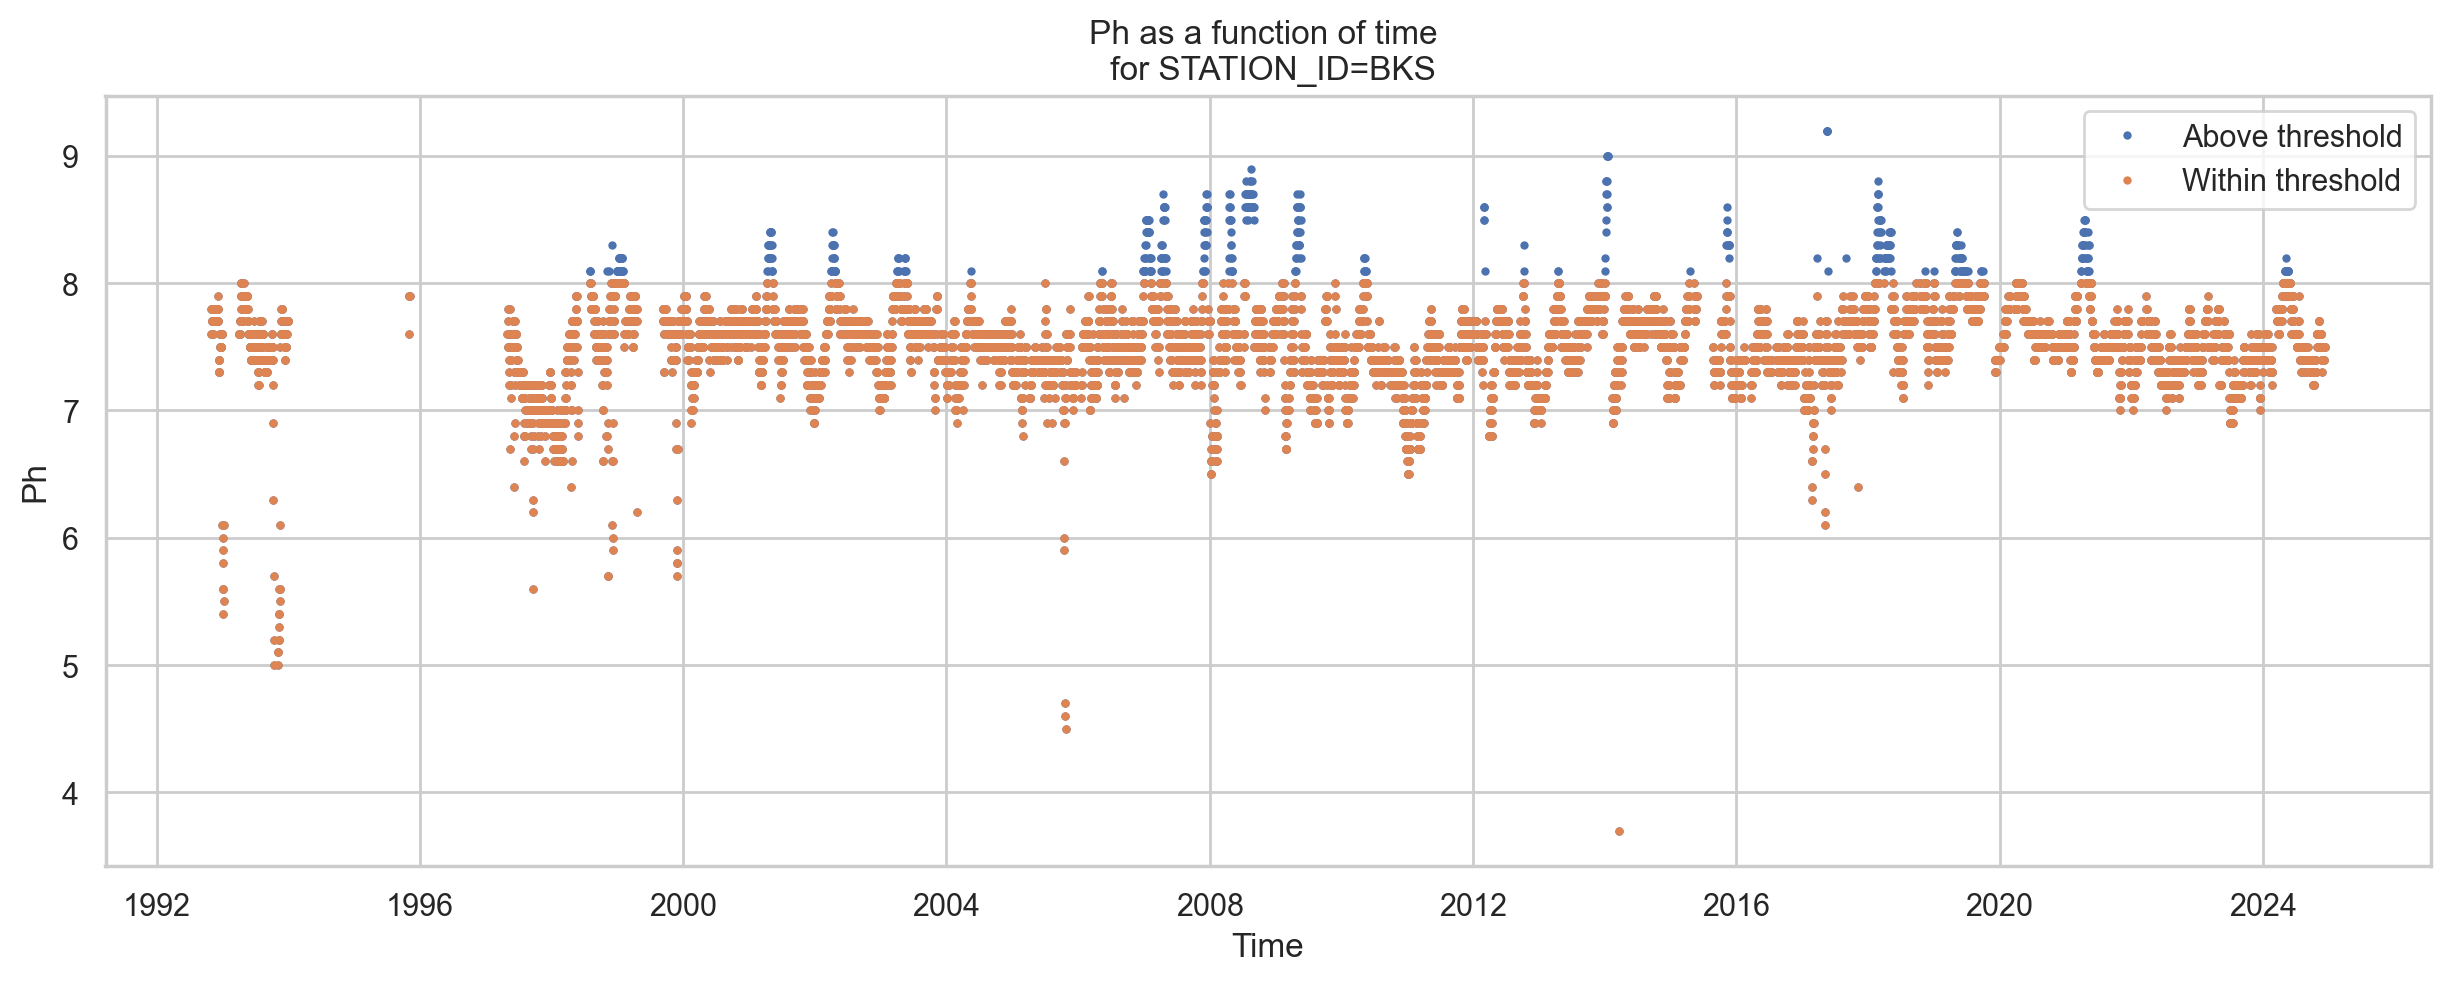

In [84]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(15,5))
plt.plot(df.TIME, df.VALUE, marker='o', markersize=2, linestyle='None', label='Above threshold')
plt.plot(df.TIME, df.threshold, marker='o', markersize=2, linestyle='None', label='Within threshold')
ax.set_xlabel('Time')
ax.set_ylabel('Ph')
ax.set_title('Ph as a function of time \n for STATION_ID=BKS')
ax.legend()